In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [2]:
test = pd.read_csv('/kaggle/input/chat-gpt-generated-text-detection/test.csv')
test.head() 


,id,text
0,68113,There have been 50 online bomb threats made si...
1,19660,"Haifa Port, situated on the Mediterranean coas..."
2,79151,Connecticut Senator Richard Blumenthal had a s...
3,8415,Ohio's governor on Friday signed an executive ...
4,12307,"Kadaram was not the only target of the attack,..."


In [3]:
train = pd.read_csv('/kaggle/input/chat-gpt-generated-text-detection/train.csv')
train.head()

,id,text,author
0,3161,A new service called Twitter Alerts has been a...,chatgpt
1,24964,Swansea City fans will be delighted to hear th...,chatgpt
2,22861,Ready to go: Ross McCormack took part in Fulha...,person
3,68204,Penn Station is the busiest transportation hub...,chatgpt
4,10289,"The government, which had been the guarantor o...",chatgpt


In [4]:
combined = pd.concat([train,test])
combined.head()

,id,text,author
0,3161,A new service called Twitter Alerts has been a...,chatgpt
1,24964,Swansea City fans will be delighted to hear th...,chatgpt
2,22861,Ready to go: Ross McCormack took part in Fulha...,person
3,68204,Penn Station is the busiest transportation hub...,chatgpt
4,10289,"The government, which had been the guarantor o...",chatgpt


In [5]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93999 entries, 0 to 9398
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      93999 non-null  int64 
 1   text    93999 non-null  object
 2   author  84600 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.9+ MB


In [6]:
combined.dtypes

id         int64
text      object
author    object
dtype: object

In [7]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,93999.0,47000.0,27135.318314,1.0,23500.5,47000.0,70499.5,93999.0


In [8]:
combined.isnull().sum()/len(combined)*100

id        0.000000
text      0.000000
author    9.999043
dtype: float64

In [11]:
combined.kurt

<bound method DataFrame.kurt of          id                                               text   author
0      3161  A new service called Twitter Alerts has been a...  chatgpt
1     24964  Swansea City fans will be delighted to hear th...  chatgpt
2     22861  Ready to go: Ross McCormack took part in Fulha...   person
3     68204  Penn Station is the busiest transportation hub...  chatgpt
4     10289  The government, which had been the guarantor o...  chatgpt
...     ...                                                ...      ...
9394  84010  It's likely someone from Hong Kong has just be...      NaN
9395    241  Calvin Veltman undertook, for the National Cen...      NaN
9396  24258  I was so paranoid I might find a lump that I e...      NaN
9397  26109  By . Laura Powell . PUBLISHED: . 16:13 EST, 3 ...      NaN
9398  60456  Some Neptune trojans are remarkably stable in ...      NaN

[93999 rows x 3 columns]>

In [12]:

combined.skew

<bound method DataFrame.skew of          id                                               text   author
0      3161  A new service called Twitter Alerts has been a...  chatgpt
1     24964  Swansea City fans will be delighted to hear th...  chatgpt
2     22861  Ready to go: Ross McCormack took part in Fulha...   person
3     68204  Penn Station is the busiest transportation hub...  chatgpt
4     10289  The government, which had been the guarantor o...  chatgpt
...     ...                                                ...      ...
9394  84010  It's likely someone from Hong Kong has just be...      NaN
9395    241  Calvin Veltman undertook, for the National Cen...      NaN
9396  24258  I was so paranoid I might find a lump that I e...      NaN
9397  26109  By . Laura Powell . PUBLISHED: . 16:13 EST, 3 ...      NaN
9398  60456  Some Neptune trojans are remarkably stable in ...      NaN

[93999 rows x 3 columns]>

In [13]:
combined.shape

(93999, 3)

<Axes: >

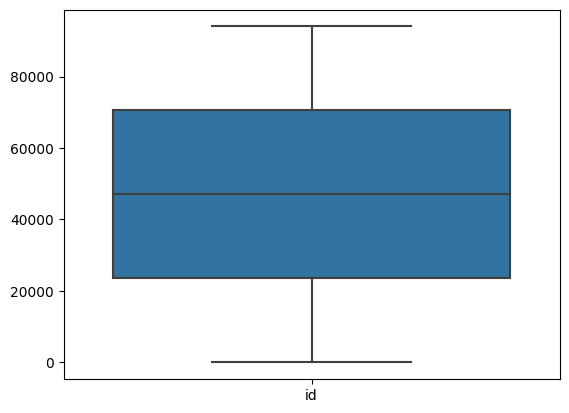

In [17]:
sns.boxplot(combined)

<Axes: >

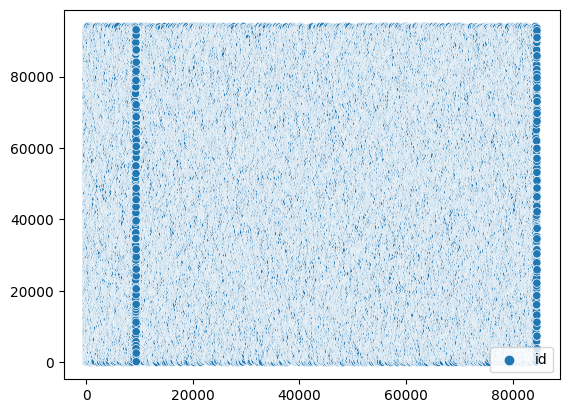

In [18]:
sns.scatterplot(combined)

<Axes: >

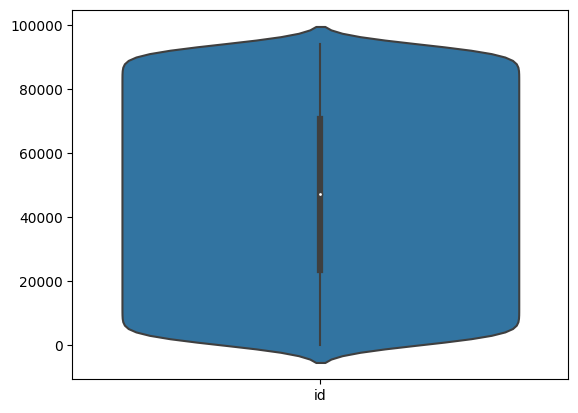

In [19]:
sns.violinplot(combined) 

<Axes: >

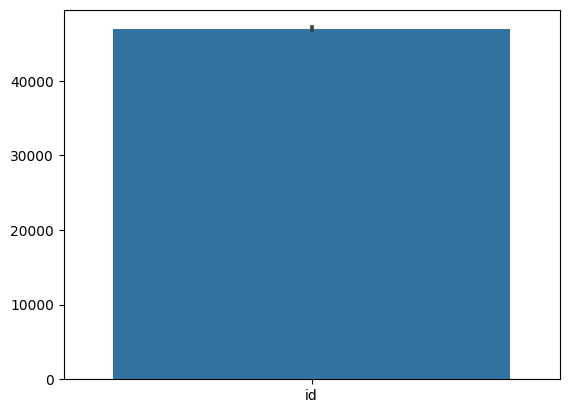

In [20]:
sns.barplot(combined)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: ylabel='Count'>

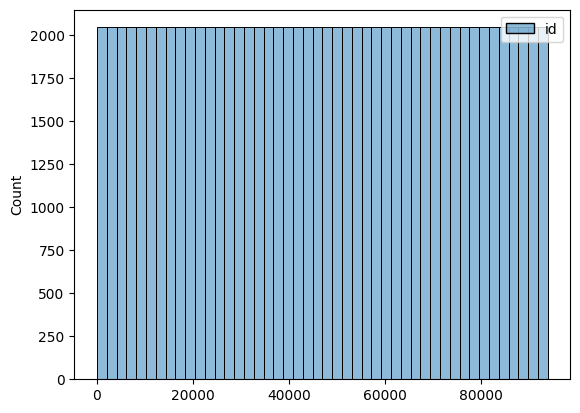

In [21]:
sns.histplot(combined)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


<Axes: ylabel='Density'>

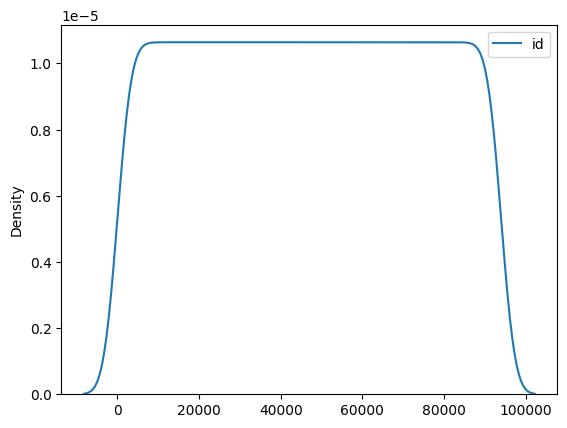

In [22]:
sns.kdeplot(combined)


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


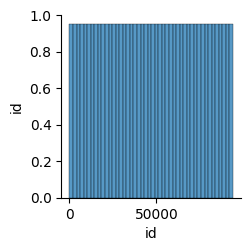

In [24]:
sns.pairplot(combined)

In [25]:
cat_cols = combined.select_dtypes(include='object')

In [26]:
for i in cat_cols:
    combined[i].value_counts()
    print(i)
    print(''*50)

text

author



In [27]:

num_cols = combined.select_dtypes(include='number')

In [28]:
for i in num_cols:
    combined[i].value_counts()
    print(i)
    print(''*50)

id



In [29]:
combined['id']=combined['id'].map({"Good":2,'Standard':1,'Poor':0})

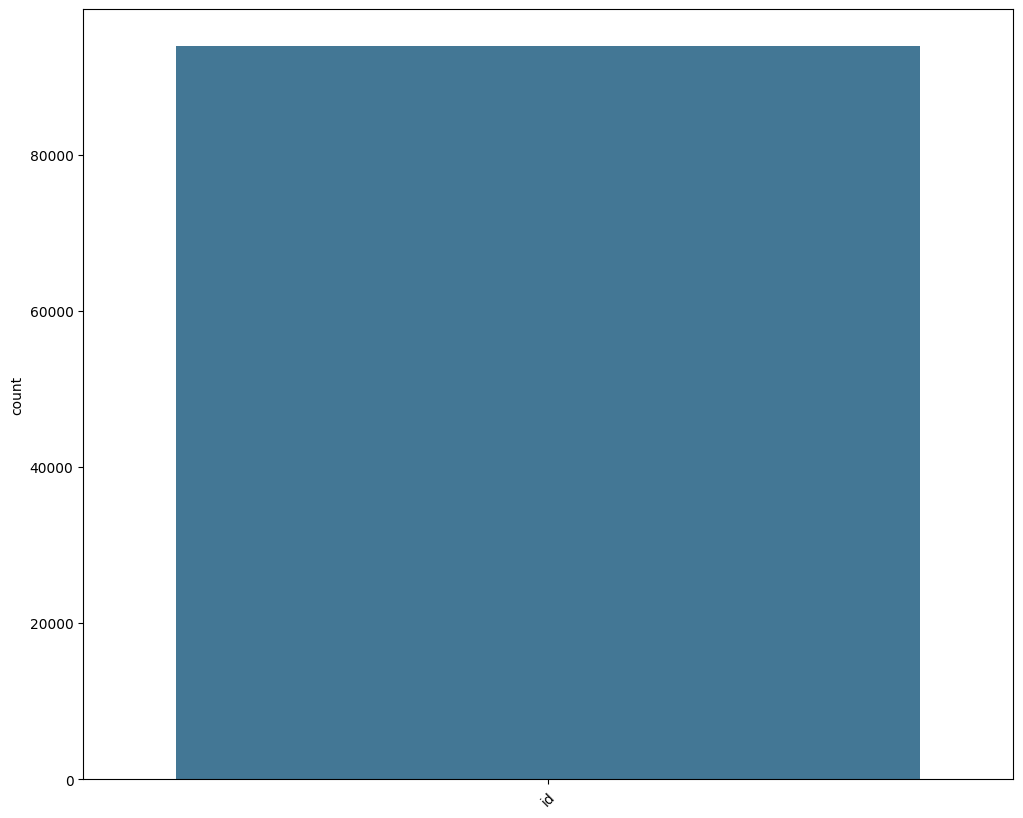

In [31]:
plt.figure(figsize=(12,10))
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=45);

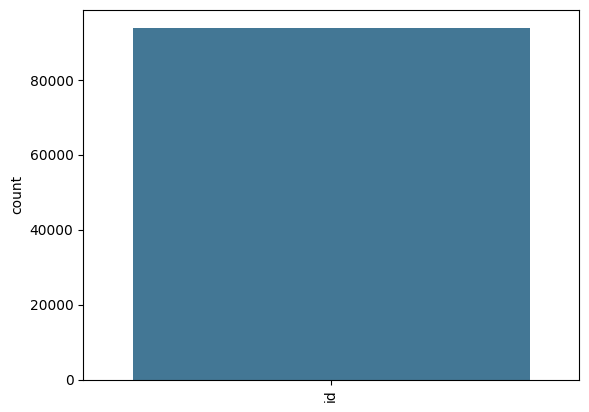

In [35]:
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=90);

(array([0]), [Text(0, 0, 'id')])

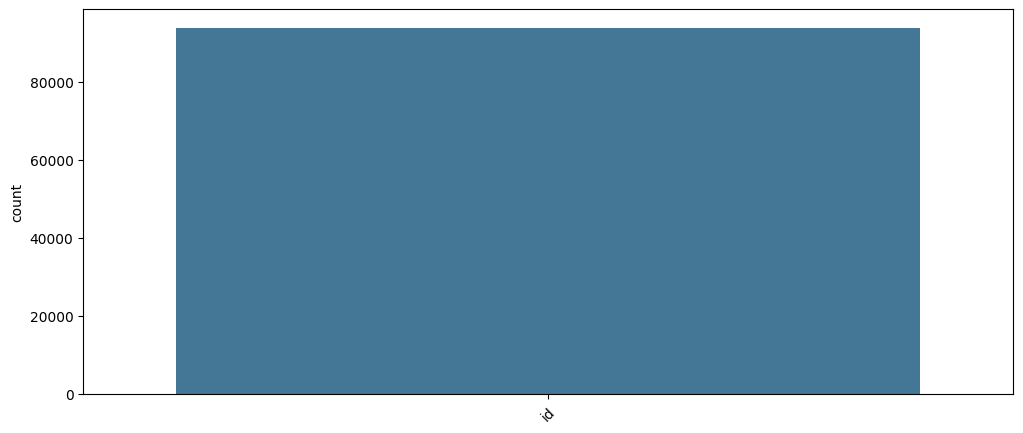

In [36]:
plt.figure(figsize=(12,5))
sns.countplot(data=combined,palette='mako')
plt.xticks(rotation=45)

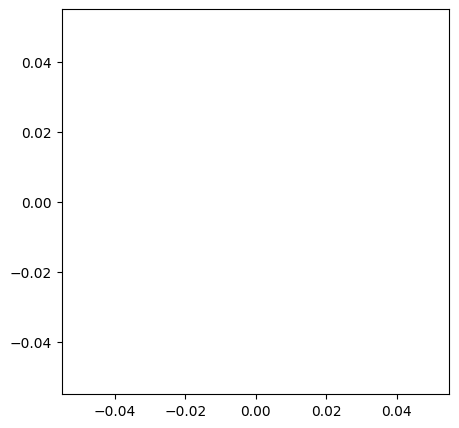

In [37]:
x=1
plt.figure(figsize=(5,5))
for i in num_cols:
    sns.histplot(data=combined,x=i)
    print('\n')
    plt.show()

In [38]:
combined['id'].value_counts()

Series([], Name: count, dtype: int64)

In [39]:
combined['id'].unique()

array([nan])

In [40]:
combined.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,id,text,author
0,NaN,A new service called Twitter Alerts has been a...,chatgpt
1,NaN,Swansea City fans will be delighted to hear th...,chatgpt
2,NaN,Ready to go: Ross McCormack took part in Fulha...,person
3,NaN,Penn Station is the busiest transportation hub...,chatgpt
4,NaN,"The government, which had been the guarantor o...",chatgpt
